# Model Interpretability using GradCAM

In [1]:
from pathlib import Path
import numpy as np
import random
import json

import torch
import torch.nn.functional as F
from torchinfo import summary
from torchvision import models, transforms as T

import cv2
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import colormaps

## System Config

In [2]:
def system_config(SEED_VALUE=42) -> tuple[torch.device, bool]:
    random.seed(SEED_VALUE)
    np.random.seed(SEED_VALUE)
    torch.manual_seed(SEED_VALUE)

    if torch.cuda.is_available():
        print("Using CUDA GPU")

        torch.cuda.manual_seed(SEED_VALUE)
        torch.cuda.manual_seed_all(SEED_VALUE)

        # Performance and deterministic behavior.
        torch.backends.cudnn.enabled = (
            True  # Provides highly optimized primitives for DL operations.
        )
        torch.backends.cudnn.deterministic = (
            True  # Insures deterministic even when above cudnn is enabled.
        )
        torch.backends.cudnn.benchmark = (
            False  # Setting to True can cause non-deterministic behavior.
        )

        return torch.device("cuda"), True

    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        import os

        print("Using Apple Silicon GPU")

        # Environment variable that allows PyTorch to fall back to CPU execution
        # when encountering operations that are not currently supported by MPS.
        os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

        torch.mps.manual_seed(SEED_VALUE)
        torch.use_deterministic_algorithms(True)

        return torch.device("mps"), True

    print("Using CPU")
    torch.use_deterministic_algorithms(True)

    return torch.device("cpu"), False

In [3]:
DEVICE, GPU_AVAILABLE = system_config()

Using Apple Silicon GPU


## Build ImageNet Dictionary

In [4]:
ROOT = Path().resolve()
json_path = ROOT / "imagenet_class_index.json"

imagenet_class_index = json.load(open(json_path))
class_name_dict = dict()
for idx in range(len(imagenet_class_index)):
    class_name_dict[idx] = imagenet_class_index[str(idx)][1]

In [5]:
print(class_name_dict)

{0: 'tench', 1: 'goldfish', 2: 'great_white_shark', 3: 'tiger_shark', 4: 'hammerhead', 5: 'electric_ray', 6: 'stingray', 7: 'cock', 8: 'hen', 9: 'ostrich', 10: 'brambling', 11: 'goldfinch', 12: 'house_finch', 13: 'junco', 14: 'indigo_bunting', 15: 'robin', 16: 'bulbul', 17: 'jay', 18: 'magpie', 19: 'chickadee', 20: 'water_ouzel', 21: 'kite', 22: 'bald_eagle', 23: 'vulture', 24: 'great_grey_owl', 25: 'European_fire_salamander', 26: 'common_newt', 27: 'eft', 28: 'spotted_salamander', 29: 'axolotl', 30: 'bullfrog', 31: 'tree_frog', 32: 'tailed_frog', 33: 'loggerhead', 34: 'leatherback_turtle', 35: 'mud_turtle', 36: 'terrapin', 37: 'box_turtle', 38: 'banded_gecko', 39: 'common_iguana', 40: 'American_chameleon', 41: 'whiptail', 42: 'agama', 43: 'frilled_lizard', 44: 'alligator_lizard', 45: 'Gila_monster', 46: 'green_lizard', 47: 'African_chameleon', 48: 'Komodo_dragon', 49: 'African_crocodile', 50: 'American_alligator', 51: 'triceratops', 52: 'thunder_snake', 53: 'ringneck_snake', 54: 'hogn

## Load ResNet34 Pre-Trained Model

In [6]:
model = models.resnet34(weights="DEFAULT")
print(
    summary(
        model, input_size=(1, 3, 224, 224), device="cpu", row_settings=["var_names"]
    )
)

Layer (type (var_name))                  Output Shape              Param #
ResNet (ResNet)                          [1, 1000]                 --
├─Conv2d (conv1)                         [1, 64, 112, 112]         9,408
├─BatchNorm2d (bn1)                      [1, 64, 112, 112]         128
├─ReLU (relu)                            [1, 64, 112, 112]         --
├─MaxPool2d (maxpool)                    [1, 64, 56, 56]           --
├─Sequential (layer1)                    [1, 64, 56, 56]           --
│    └─BasicBlock (0)                    [1, 64, 56, 56]           --
│    │    └─Conv2d (conv1)               [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d (bn1)            [1, 64, 56, 56]           128
│    │    └─ReLU (relu)                  [1, 64, 56, 56]           --
│    │    └─Conv2d (conv2)               [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d (bn2)            [1, 64, 56, 56]           128
│    │    └─ReLU (relu)                  [1, 64, 56, 56]           --
│

## Function to Pre-process Image for Inference

In [7]:
mean = [0.485, 0.456, 0.406]
stddev = [0.229, 0.224, 0.225]


def image_preprocess_transforms(img_size=(224, 224)):
    return T.Compose(
        [
            T.Resize(img_size, antialias=True),
            T.ToTensor(),
            T.Normalize(mean=mean, std=stddev),
        ]
    )

In [8]:
def process_image(img_path, size=(224, 224)):
    rgb_image = Image.open(img_path).convert("RGB")
    image_np = np.array(rgb_image)

    preprocesser = image_preprocess_transforms(img_size=size)
    img_transformed = preprocesser(rgb_image)
    return image_np, img_transformed

## Function to generate Grad-CAM Heatmap

In [9]:
def get_model_outputs(model, img_tensor, layer_name):
    model.eval()

    x = img_tensor
    layer_conv_op = None

    for name, child in model.named_children():
        # Flatten the output keeping the batch size, before passing through the Linear layer.
        if name == "fc":
            x = torch.flatten(x, 1)

        x = getattr(model, name)(x)
        if name == layer_name:
            layer_conv_op = x

    return layer_conv_op, x

In [10]:
def generate_gradcam_heatmap(img_transformed, model, layer_last_name, pred_index=None):
    last_conv_layer_output, predictions = get_model_outputs(
        model, img_transformed, layer_last_name
    )

    if not pred_index:
        pred_index = torch.argmax(predictions.squeeze(0))

    class_channel = predictions[:, pred_index]

    # Compute the gradient of the output neuron (top predicted or chosen) with
    # respect to the feature map activations across all the blocks of the ResNet model.
    # However, we are only concerned about the gradients with respect to last_conv_layer_output
    # and hence we have its hook registered to store the gradients accordingly.
    # Each gradient (map) has the same (2D) shape as the activation maps.
    layer_gradients = []
    hook = last_conv_layer_output.register_hook(
        lambda grad: layer_gradients.append(grad.detach())
    )
    class_channel.sum().backward()

    # Perform global average pooling on each gradient map.
    # These are the alpha values that will be used to weight each activation map.
    pooled_grads = torch.mean(layer_gradients[0], (0, 2, 3))

    # Reshape the tensor from [B, C, H, W] to [B, H, W, C]
    reshaped = last_conv_layer_output[0].permute(1, 2, 0).detach()

    heatmap = reshaped @ pooled_grads
    heatmap = heatmap.clamp(min=0.0) / heatmap.max()

    # Remove the registered hooks.
    hook.remove()

    return heatmap.numpy()

## Function to display Heatmap overlayed on Image

In [11]:
cmap = colormaps["jet"]
colours = cmap(np.arange(256))[:, :3]


def display_heatmap(image, heatmap):
    height, width = image.shape[:2]

    heatmap = cv2.resize(heatmap, (width, height))
    heatmap = np.uint8(255 * heatmap)
    rgb_heatmap = colours[heatmap]

    final_image = np.clip(rgb_heatmap * 0.6 + image / 255.0, 0.0, 1.0)

    images = [image, rgb_heatmap, final_image]
    plt.figure(figsize=(21, 18))
    for i in range(3):
        plt.subplot(1, 3, i + 1)
        plt.imshow(images[i])
        plt.axis("off")
        plt.tight_layout()

    plt.show()

## Grad-CAM Examples

In [12]:
last_layer_name = "layer4"

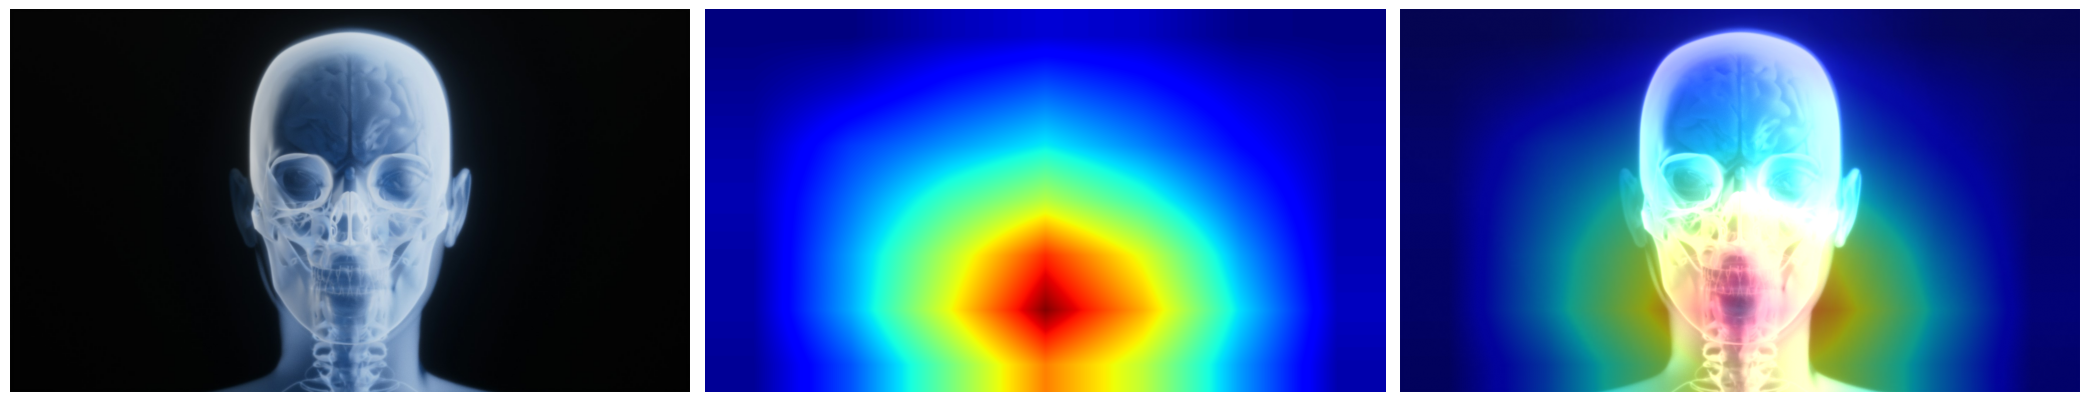

In [13]:
input_path = ROOT / "input"
image_path = input_path / "skeleton.jpg"

rgb_image, img_tensor = process_image(img_path=image_path)
img_batch = img_tensor.unsqueeze(0)

heatmap = generate_gradcam_heatmap(img_batch, model, last_layer_name)
display_heatmap(rgb_image, heatmap)

## Heatmap on an intermediate Conv Layer

In [14]:
last_layer_name = "layer2"

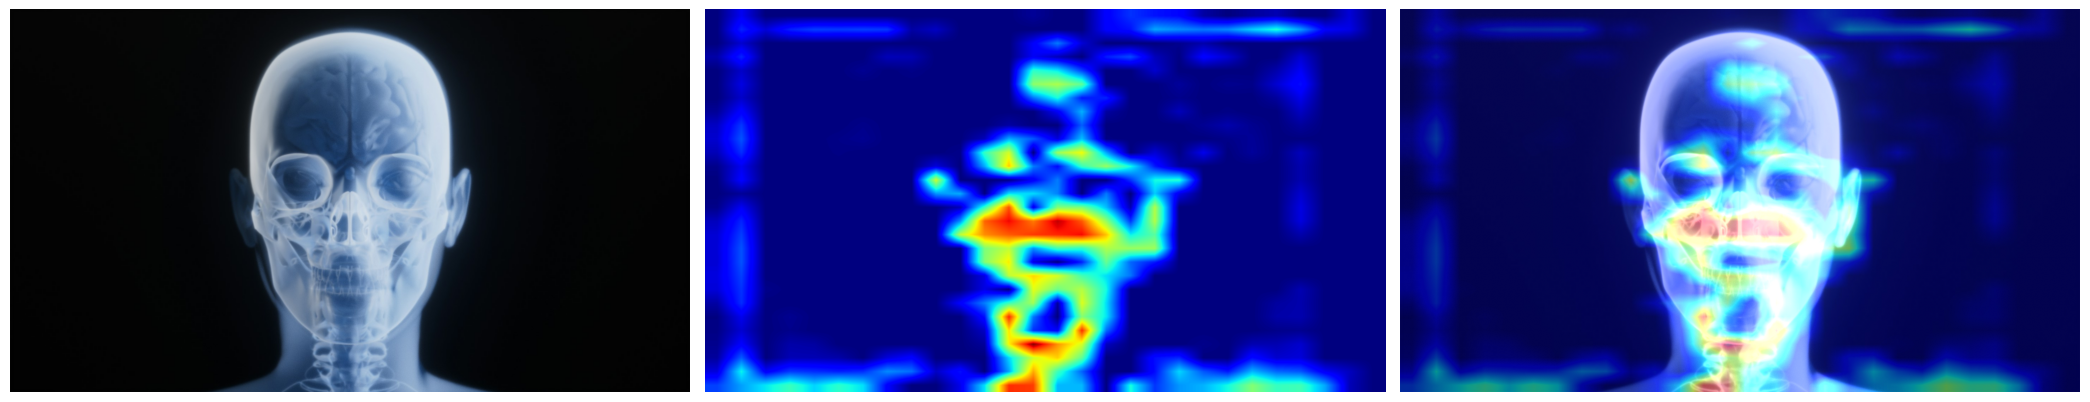

In [15]:
input_path = ROOT / "input"
image_path = input_path / "skeleton.jpg"

rgb_image, img_tensor = process_image(img_path=image_path)
img_batch = img_tensor.unsqueeze(0)

heatmap = generate_gradcam_heatmap(img_batch, model, last_layer_name)
display_heatmap(rgb_image, heatmap)

## Top-K Predictions

In [16]:
last_layer_name = "layer4"


def generate_gradcam_topk(model, topk, input_path: Path, output_dir: Path):
    img_index = 1
    img_paths = sorted(input_path.glob("*"))
    imgs_len = len(img_paths)

    output_path = Path(output_dir)
    output_path.mkdir(exist_ok=True)

    for img_path in input_path.glob("*"):
        model.eval()

        rgb_image, img_tensor = process_image(img_path)
        image_batch = img_tensor.unsqueeze(0)

        with torch.no_grad():
            pred_logits = model(image_batch)

        pred_scores = F.softmax(pred_logits, dim=1).squeeze()
        pred_topk, class_topk = torch.topk(pred_scores, k=topk)

        height, width = rgb_image.shape[:2]

        fig = plt.figure(figsize=(topk * 7, 18))

        for idx, (score, cls_id) in enumerate(zip(pred_topk, class_topk)):
            class_label = class_name_dict[int(cls_id)]
            class_index = cls_id

            heatmap = generate_gradcam_heatmap(
                image_batch, model, last_layer_name, pred_index=class_index
            )
            heatmap = cv2.resize(heatmap, (width, height))
            heatmap = np.uint8(255 * heatmap)
            rgb_heatmap = colours[heatmap]

            final_image = np.clip(rgb_heatmap * 0.6 + rgb_image / 255.0, 0.0, 1.0)

            plt.subplot(1, topk, idx + 1)
            plt.imshow(final_image)
            plt.title(f"{class_label}: {score}")
            plt.axis("off")

        plt.tight_layout()
        save_path = output_dir / f"gradcam_{img_path.stem}.png"
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
        plt.close(fig)
        print(f"Saved: {save_path}")

In [18]:
generate_gradcam_topk(model, 3, input_path, ROOT / "output")

Saved: /Users/tapasyagutta/workspace/deep-learning/deep-learning-projects/basics/gradCAM/output/gradcam_groceries-paper-bags.png
Saved: /Users/tapasyagutta/workspace/deep-learning/deep-learning-projects/basics/gradCAM/output/gradcam_beijing.png
Saved: /Users/tapasyagutta/workspace/deep-learning/deep-learning-projects/basics/gradCAM/output/gradcam_jackal.png
Saved: /Users/tapasyagutta/workspace/deep-learning/deep-learning-projects/basics/gradCAM/output/gradcam_bathroom.png
Saved: /Users/tapasyagutta/workspace/deep-learning/deep-learning-projects/basics/gradCAM/output/gradcam_big-ben.png
Saved: /Users/tapasyagutta/workspace/deep-learning/deep-learning-projects/basics/gradCAM/output/gradcam_dog-boy.png
Saved: /Users/tapasyagutta/workspace/deep-learning/deep-learning-projects/basics/gradCAM/output/gradcam_chairs-tables.png
Saved: /Users/tapasyagutta/workspace/deep-learning/deep-learning-projects/basics/gradCAM/output/gradcam_sign-posts.png
Saved: /Users/tapasyagutta/workspace/deep-learning